<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/aishwarya_SIA_analysis_27725.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import numpy as np

In [58]:
df = pd.read_excel('/content/drive/MyDrive/Aishwarya thesis clean dataset 27725.xlsx')

In [59]:
df

,name,age,gender,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,1wk kv,1wk axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,44.25,10
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,44.25,70
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,45.00,5
...,...,...,...,...,...,...,...,...,...,...,...,...
102,kamalamma,61,F,43.00,43.50,100,43.00,43.75,170,43.00,43.50,180
103,gundamma,54,F,45.75,46.25,30,45.75,47.00,5,46.25,45.75,15
104,sakamma,67,F,45.25,46.00,135,44.25,45.50,155,45.25,45.75,150
105,kenchangowda patil,61,M,46.00,46.50,40,46.25,48.00,5,46.25,47.00,30


In [60]:
df.shape, df.columns

((107, 12),
 Index(['name', 'age', 'gender', 'preop kh', 'preop kv', 'preop axis',
        'postop kh', 'postop kv', 'postop axis', '1wk kh', '1wk kv',
        '1wk axis'],
       dtype='object'))

In [61]:
df = df.drop(['name'], axis=1)
df

,age,gender,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,1wk kv,1wk axis
0,60,M,43.50,44.00,90,43.25,44.75,10,43.75,44.25,10
1,64,M,44.25,44.50,45,41.25,44.50,70,41.75,44.25,70
2,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
4,58,M,44.25,44.75,85,44.50,45.50,40,44.25,45.00,5
...,...,...,...,...,...,...,...,...,...,...,...
102,61,F,43.00,43.50,100,43.00,43.75,170,43.00,43.50,180
103,54,F,45.75,46.25,30,45.75,47.00,5,46.25,45.75,15
104,67,F,45.25,46.00,135,44.25,45.50,155,45.25,45.75,150
105,61,M,46.00,46.50,40,46.25,48.00,5,46.25,47.00,30


In [62]:
df['age'].describe()

,age
count,107.000000
mean,65.551402
std,5.257939
min,50.000000
25%,63.000000
50%,67.000000
75%,69.000000
max,75.000000


In [63]:
df.isnull().sum()

,0
age,0
gender,0
preop kh,0
preop kv,0
preop axis,0
postop kh,0
postop kv,0
postop axis,0
1wk kh,0
1wk kv,0


<Axes: >

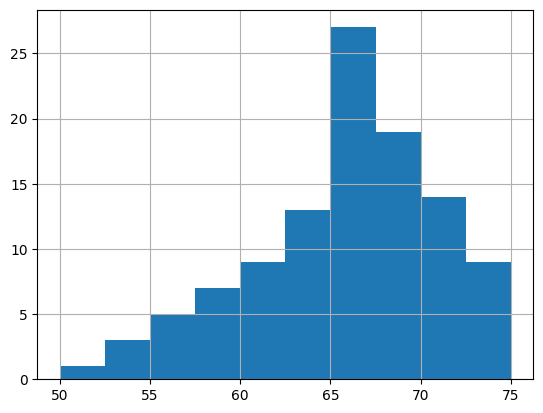

In [64]:
df['age'].hist()

In [65]:
df['age'].value_counts()

,count
age,
65,12
67,12
68,10
70,10
69,9
63,7
59,6
64,6
60,4


<Axes: >

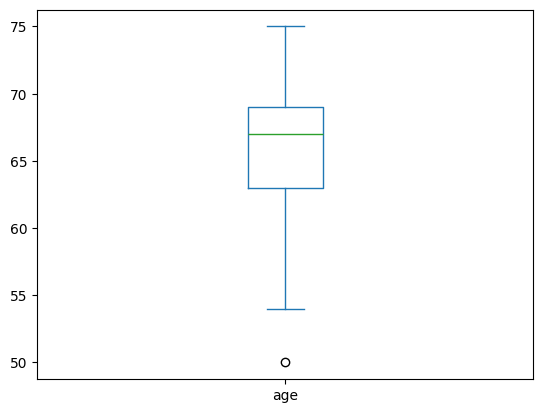

In [66]:
df['age'].plot.box()

In [67]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

print(f"Original shape: {df.shape}")
print(f"Shape after removing outliers: {df_filtered.shape}")
display(df_filtered.head())

Original shape: (107, 11)
Shape after removing outliers: (106, 11)


,age,gender,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,1wk kv,1wk axis
0,60,M,43.50,44.00,90,43.25,44.75,10,43.75,44.25,10
1,64,M,44.25,44.50,45,41.25,44.50,70,41.75,44.25,70
2,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
4,58,M,44.25,44.75,85,44.50,45.50,40,44.25,45.00,5


In [75]:
df_male = df_filtered[df_filtered['gender'] == 'M']

Q1_male = df_male['age'].quantile(0.25)
Q3_male = df_male['age'].quantile(0.75)
IQR_male = Q3_male - Q1_male

lower_bound_male = Q1_male - 1.5 * IQR_male
upper_bound_male = Q3_male + 1.5 * IQR_male

df_filtered_male = df_male[(df_male['age'] >= lower_bound_male) & (df_male['age'] <= upper_bound_male)]

# Update df_filtered to include the filtered male data and the original female data
df_filtered = pd.concat([df_filtered[df_filtered['gender'] == 'F'], df_filtered_male])

print(f"Original male shape: {df_male.shape}")
print(f"Shape after removing male age outliers: {df_filtered_male.shape}")
print(f"Updated df_filtered shape: {df_filtered.shape}")
display(df_filtered.head())

Original male shape: (49, 11)
Shape after removing male age outliers: (48, 11)
Updated df_filtered shape: (104, 11)


,age,gender,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,1wk kv,1wk axis
2,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
6,63,F,44.50,45.50,75,43.50,45.00,20,44.00,44.75,100
8,59,F,44.25,44.50,110,44.25,44.50,150,44.25,44.50,150
9,60,F,44.25,44.75,90,43.50,44.50,80,43.50,44.50,80


In [69]:
df_filtered.shape

(105, 11)

In [70]:
display(df_filtered.groupby('gender')['age'].describe())

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,56.0,65.160714,4.997369,54.0,62.0,66.5,69.0,75.0
M,49.0,66.551020,4.839341,55.0,64.0,67.0,69.0,75.0


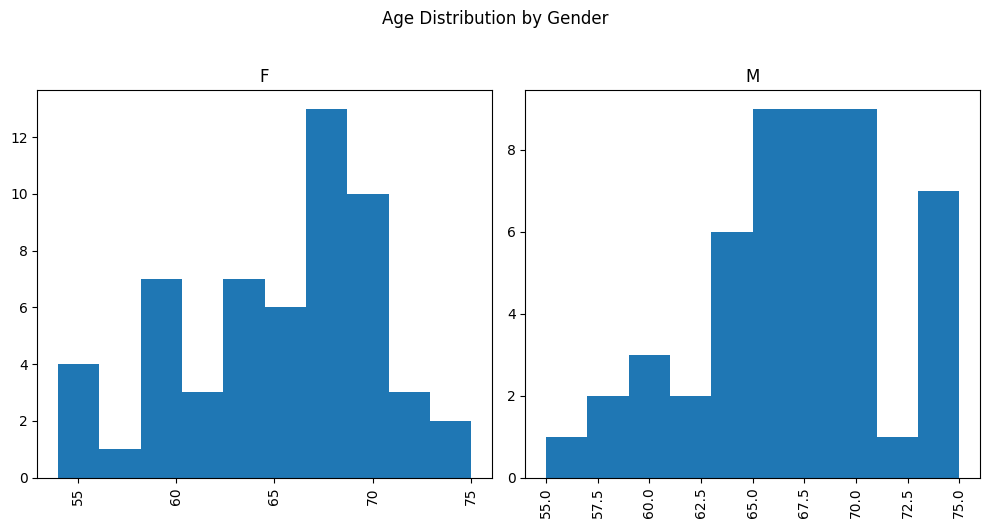

In [71]:
import matplotlib.pyplot as plt

df_filtered.hist(column='age', by='gender', bins=10, figsize=(10, 5))
plt.suptitle('Age Distribution by Gender', y=1.02)
plt.tight_layout()
plt.show()

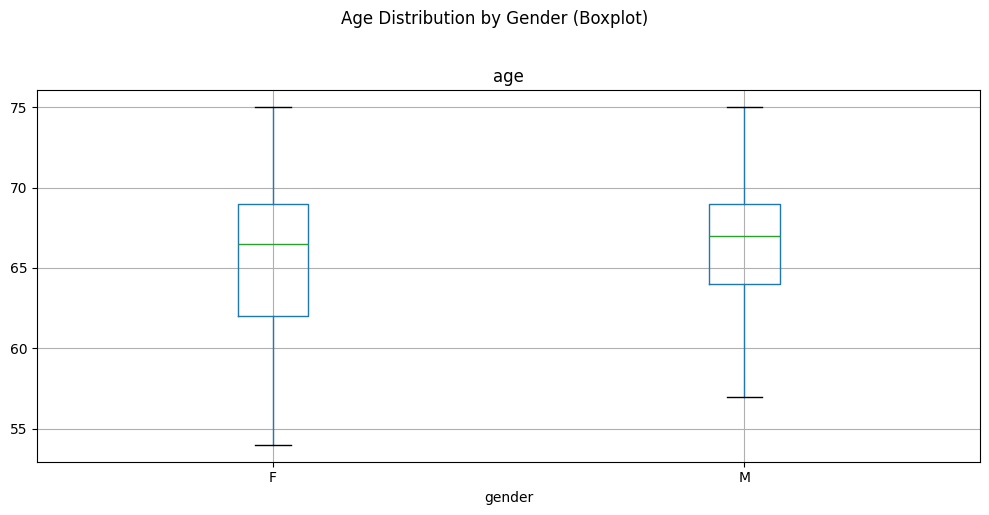

In [77]:
df_filtered.boxplot(column='age', by='gender', figsize=(10, 5))
plt.suptitle('Age Distribution by Gender (Boxplot)', y=1.02)
plt.tight_layout()
plt.show()

In [76]:
df_filtered_male.shape

(48, 11)

In [78]:
df_filtered

,age,gender,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,1wk kv,1wk axis
2,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
6,63,F,44.50,45.50,75,43.50,45.00,20,44.00,44.75,100
8,59,F,44.25,44.50,110,44.25,44.50,150,44.25,44.50,150
9,60,F,44.25,44.75,90,43.50,44.50,80,43.50,44.50,80
...,...,...,...,...,...,...,...,...,...,...,...
96,65,M,45.75,46.25,165,45.50,47.00,90,45.25,45.75,150
100,59,M,42.50,42.75,55,41.75,42.25,25,42.50,42.25,15
101,67,M,44.25,44.75,65,46.00,46.50,140,44.75,45.00,120
105,61,M,46.00,46.50,40,46.25,48.00,5,46.25,47.00,30


In [80]:
from scipy.stats import chi2_contingency
import pandas as pd

# Categorize age into bins
# You can adjust the bins and labels based on your specific needs
age_bins = [0, 60, 70, 100]
age_labels = ['<60', '60-70', '>70']
df_filtered['age_category'] = pd.cut(df_filtered['age'], bins=age_bins, labels=age_labels, right=False)

# Create a contingency table of gender and age categories
contingency_table = pd.crosstab(df_filtered['gender'], df_filtered['age_category'])

# Perform the Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square test results:")
print(f"Chi-square statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies table:")
display(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

Chi-square test results:
Chi-square statistic: 1.4183869199853856
P-value: 0.49204088812752034
Degrees of freedom: 2
Expected frequencies table:


age_category,<60,60-70,>70
gender,,,
F,7.0,36.615385,12.384615
M,6.0,31.384615,10.615385


In [82]:
from scipy.stats import ttest_ind

# Separate the age data by gender
age_male = df_filtered[df_filtered['gender'] == 'M']['age']
age_female = df_filtered[df_filtered['gender'] == 'F']['age']

# Perform independent samples t-test
ttest_result = ttest_ind(age_male, age_female)

print("Independent Samples t-test results (comparing mean age between genders):")
print(f"Test statistic: {ttest_result.statistic}")
print(f"P-value: {ttest_result.pvalue}")

Independent Samples t-test results (comparing mean age between genders):
Test statistic: 1.72324922272636
P-value: 0.08787362588062862


In [83]:
df_filtered.columns

Index(['age', 'gender', 'preop kh', 'preop kv', 'preop axis', 'postop kh',
       'postop kv', 'postop axis', '1wk kh', '1wk kv', '1wk axis',
       'age_category'],
      dtype='object')

In [84]:
correlation_kh = df_filtered['preop kh'].corr(df_filtered['postop kh'])
correlation_kv = df_filtered['preop kv'].corr(df_filtered['postop kv'])
correlation_axis = df_filtered['preop axis'].corr(df_filtered['postop axis'])

print(f"Correlation between preop kh and postop kh: {correlation_kh}")
print(f"Correlation between preop kv and postop kv: {correlation_kv}")
print(f"Correlation between preop axis and postop axis: {correlation_axis}")

Correlation between preop kh and postop kh: 0.7643517977166312
Correlation between preop kv and postop kv: 0.7173190590456968
Correlation between preop axis and postop axis: 0.20832254458522792


In [85]:
correlation_kh_1wk = df_filtered['preop kh'].corr(df_filtered['1wk kh'])
correlation_kv_1wk = df_filtered['preop kv'].corr(df_filtered['1wk kv'])
correlation_axis_1wk = df_filtered['preop axis'].corr(df_filtered['1wk axis'])

print(f"Correlation between preop kh and 1wk kh: {correlation_kh_1wk}")
print(f"Correlation between preop kv and 1wk kv: {correlation_kv_1wk}")
print(f"Correlation between preop axis and 1wk axis: {correlation_axis_1wk}")

Correlation between preop kh and 1wk kh: 0.8095510925286927
Correlation between preop kv and 1wk kv: 0.8060107188559623
Correlation between preop axis and 1wk axis: 0.4857173920115998


In [86]:
display(df_filtered.describe())

,age,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,1wk kv,1wk axis
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.00000,104.000000,104.000000,104.000000
mean,65.913462,44.600962,45.497596,90.865385,44.235577,46.007212,99.37500,44.646635,45.565000,111.778846
std,4.857405,1.896125,1.775813,52.502623,2.174384,2.269858,67.15685,1.928834,1.875825,56.722448
min,54.000000,39.500000,42.250000,5.000000,35.750000,40.000000,5.00000,39.750000,41.750000,5.000000
25%,63.000000,43.437500,44.250000,53.750000,43.000000,44.750000,23.75000,43.000000,44.250000,78.750000
50%,67.000000,44.500000,45.500000,95.000000,44.500000,46.000000,117.50000,44.500000,45.375000,120.000000
75%,69.000000,46.062500,46.812500,123.750000,46.000000,47.500000,165.00000,46.250000,47.000000,165.000000
max,75.000000,48.750000,49.500000,180.000000,48.000000,51.500000,180.00000,48.750000,50.250000,180.000000


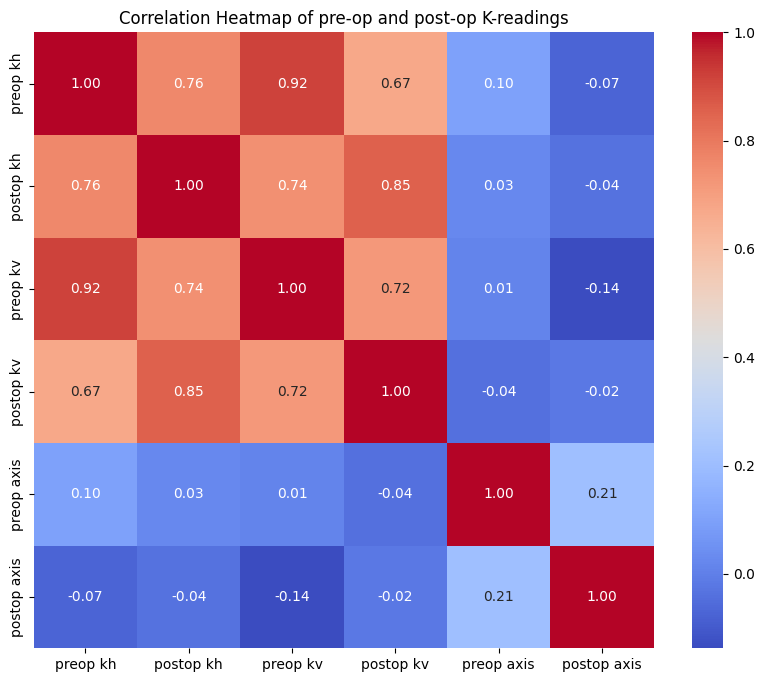

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for the heatmap
correlation_columns = ['preop kh', 'postop kh',
                       'preop kv', 'postop kv', 'preop axis','postop axis',
                       ]

correlation_matrix = df_filtered[correlation_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of pre-op and post-op K-readings')
plt.show()

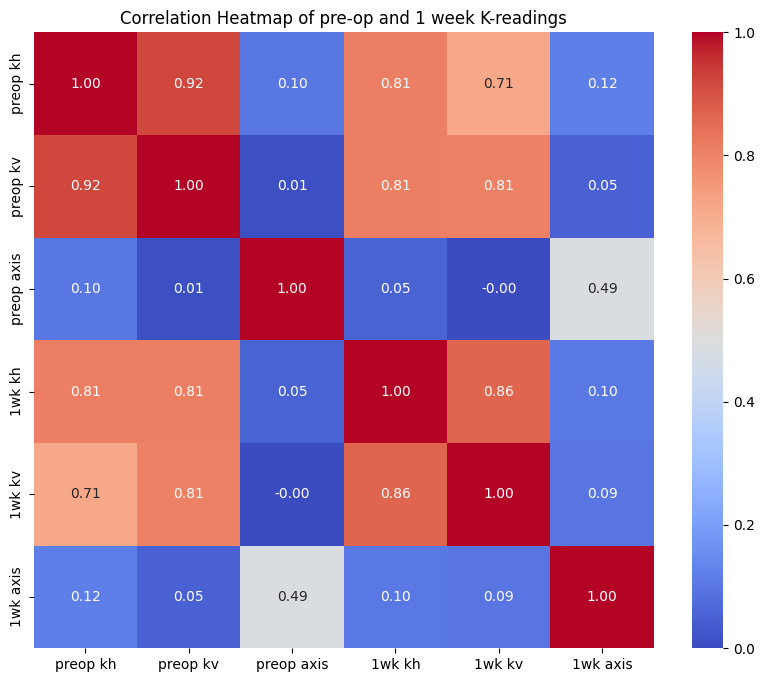

In [94]:
correlation_columns = ['preop kh', 'preop kv', 'preop axis',
                       '1wk kh', '1wk kv', '1wk axis',
                       ]

correlation_matrix = df_filtered[correlation_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of pre-op and 1 week K-readings')
plt.show()

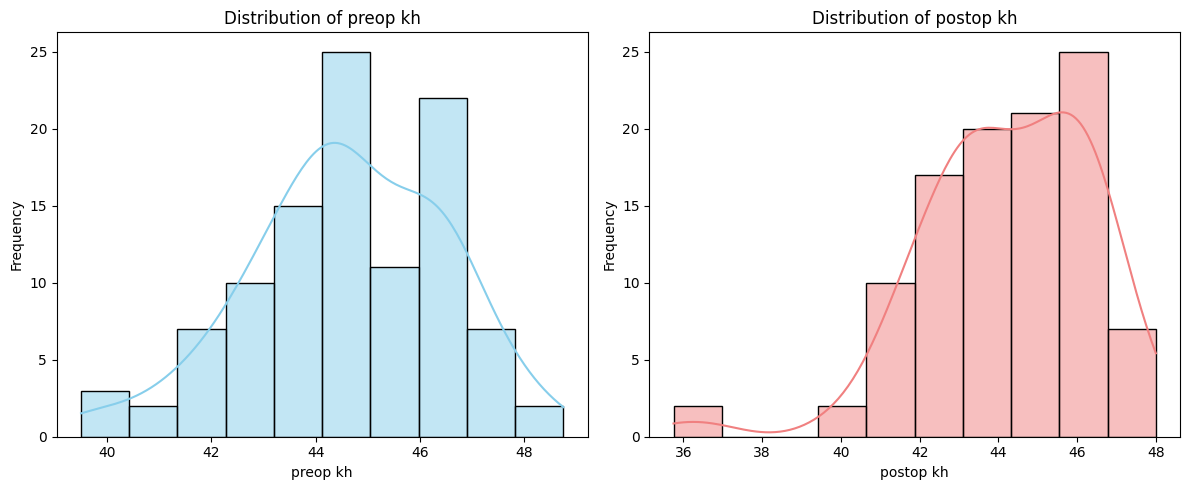

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_filtered, x='preop kh', bins=10, kde=True, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of preop kh')
axes[0].set_xlabel('preop kh')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df_filtered, x='postop kh', bins=10, kde=True, color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of postop kh')
axes[1].set_xlabel('postop kh')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

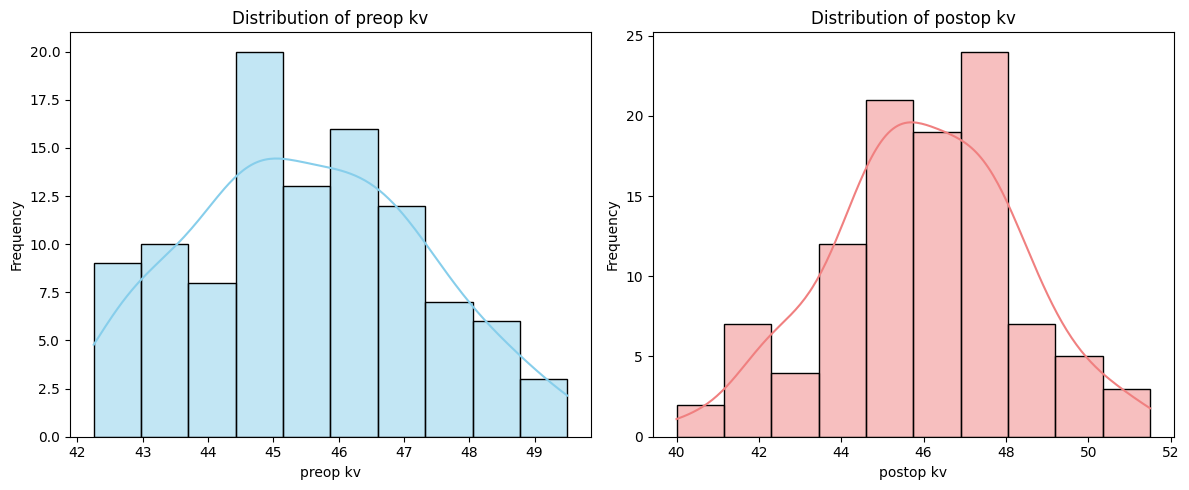

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_filtered, x='preop kv', bins=10, kde=True, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of preop kv')
axes[0].set_xlabel('preop kv')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df_filtered, x='postop kv', bins=10, kde=True, color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of postop kv')
axes[1].set_xlabel('postop kv')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

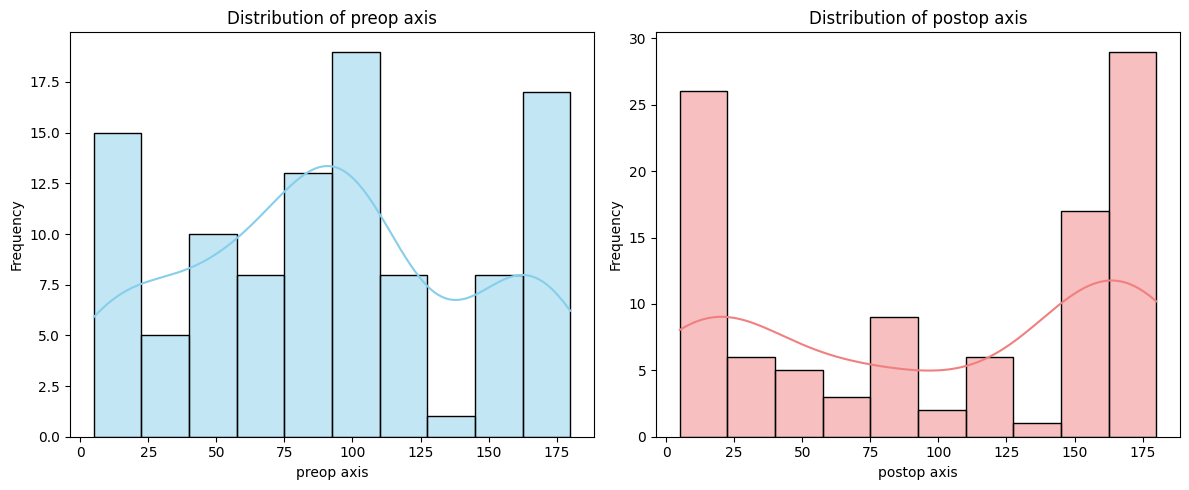

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_filtered, x='preop axis', bins=10, kde=True, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of preop axis')
axes[0].set_xlabel('preop axis')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df_filtered, x='postop axis', bins=10, kde=True, color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of postop axis')
axes[1].set_xlabel('postop axis')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

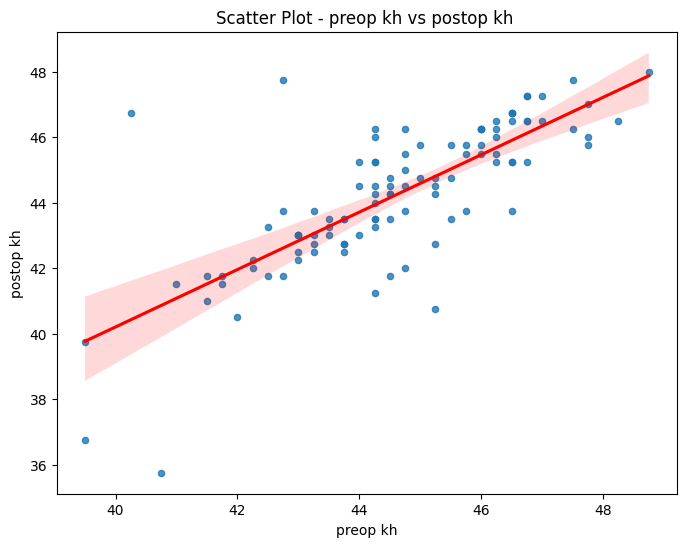

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.regplot(data=df_filtered, x='preop kh', y='postop kh', scatter_kws={'s': 20}, line_kws={'color': 'red'})
plt.title('Scatter Plot - preop kh vs postop kh ')
plt.xlabel('preop kh')
plt.ylabel('postop kh')
plt.show()

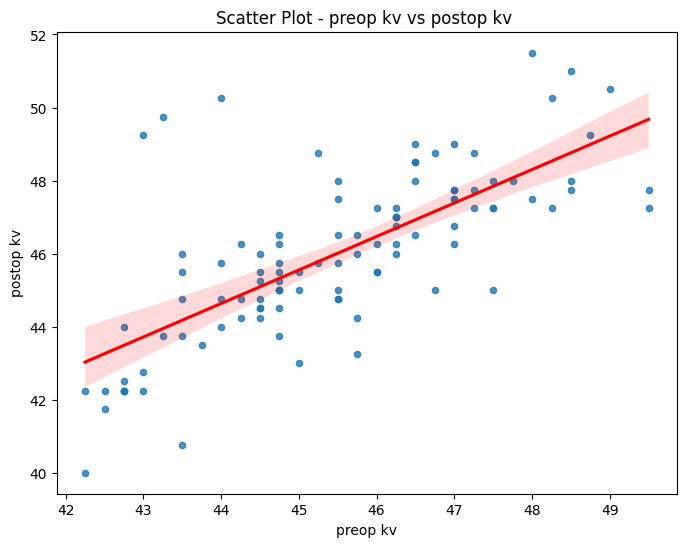

In [101]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_filtered, x='preop kv', y='postop kv', scatter_kws={'s': 20}, line_kws={'color': 'red'})
plt.title('Scatter Plot - preop kv vs postop kv ')
plt.xlabel('preop kv')
plt.ylabel('postop kv')
plt.show()

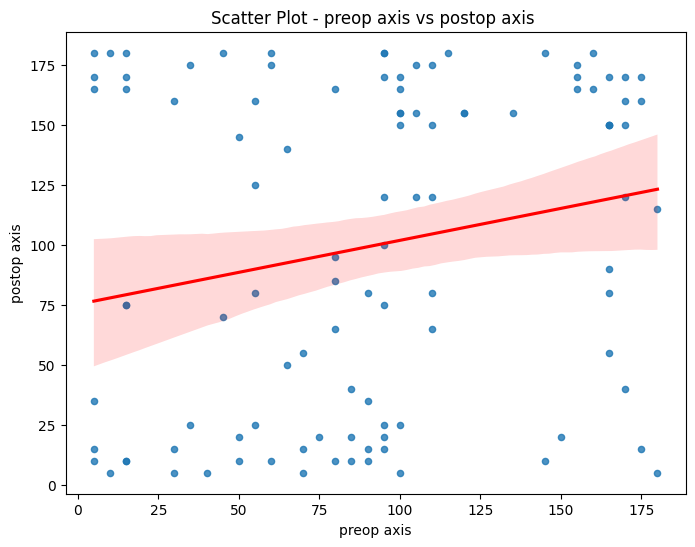

In [102]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_filtered, x='preop axis', y='postop axis', scatter_kws={'s': 20}, line_kws={'color': 'red'})
plt.title('Scatter Plot - preop axis vs postop axis ')
plt.xlabel('preop axis')
plt.ylabel('postop axis')
plt.show()

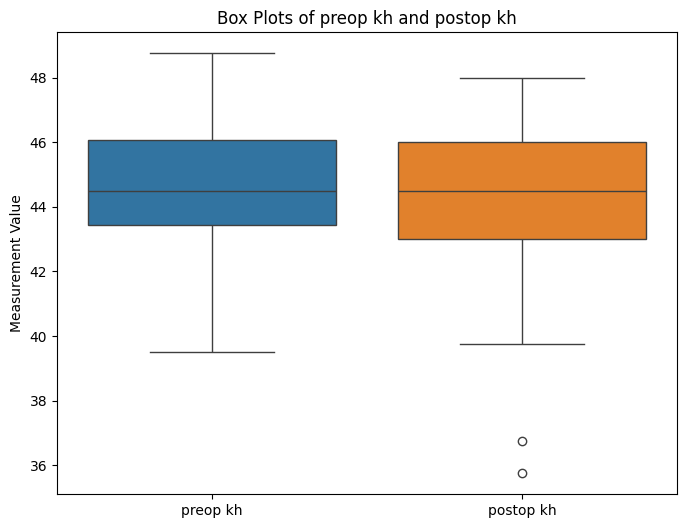

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_filtered[['preop kh', 'postop kh']])
plt.title('Box Plots of preop kh and postop kh')
plt.ylabel('Measurement Value')
plt.show()

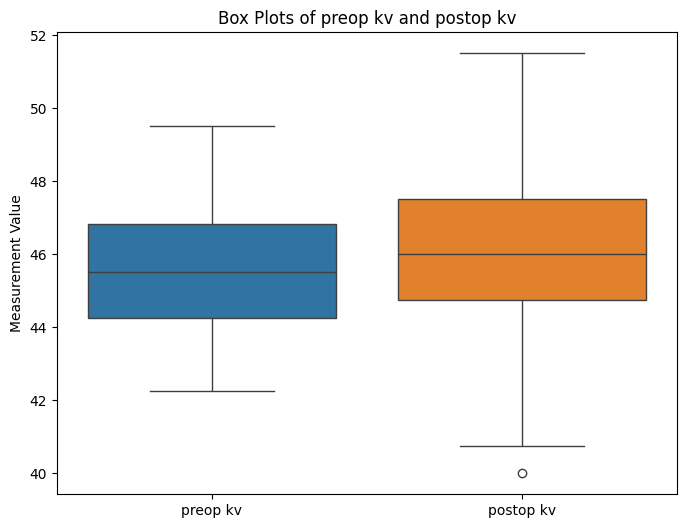

In [105]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_filtered[['preop kv', 'postop kv']])
plt.title('Box Plots of preop kv and postop kv')
plt.ylabel('Measurement Value')
plt.show()

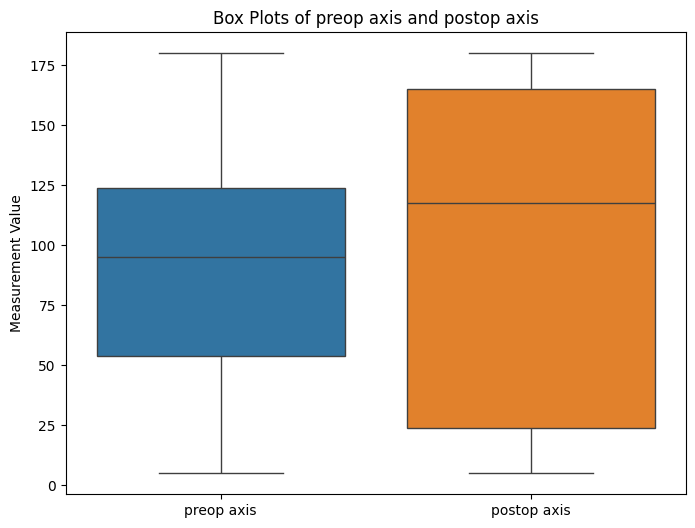

In [106]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_filtered[['preop axis', 'postop axis']])
plt.title('Box Plots of preop axis and postop axis')
plt.ylabel('Measurement Value')
plt.show()

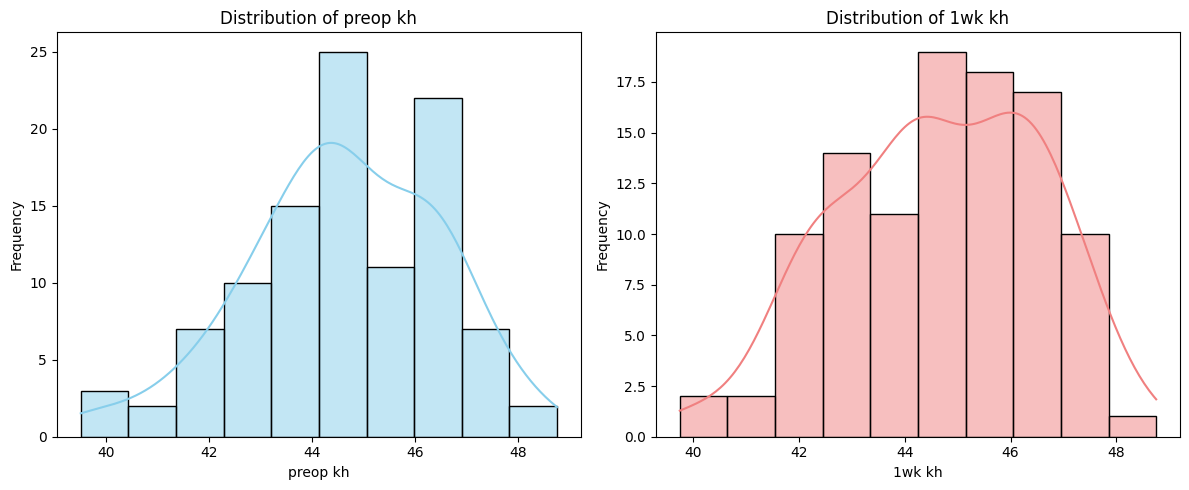

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_filtered, x='preop kh', bins=10, kde=True, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of preop kh')
axes[0].set_xlabel('preop kh')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df_filtered, x='1wk kh', bins=10, kde=True, color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of 1wk kh')
axes[1].set_xlabel('1wk kh')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

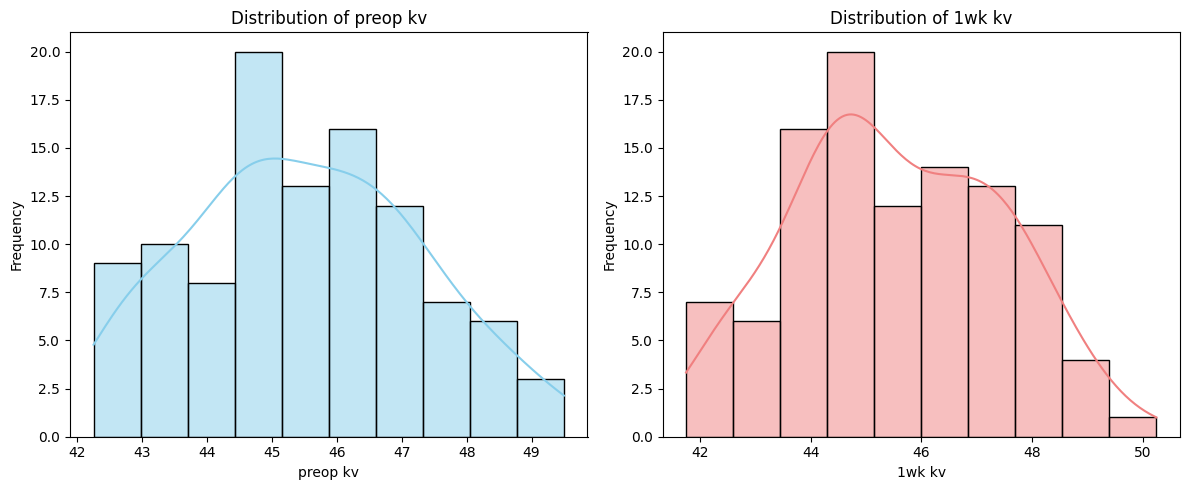

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_filtered, x='preop kv', bins=10, kde=True, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of preop kv')
axes[0].set_xlabel('preop kv')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df_filtered, x='1wk kv', bins=10, kde=True, color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of 1wk kv')
axes[1].set_xlabel('1wk kv')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

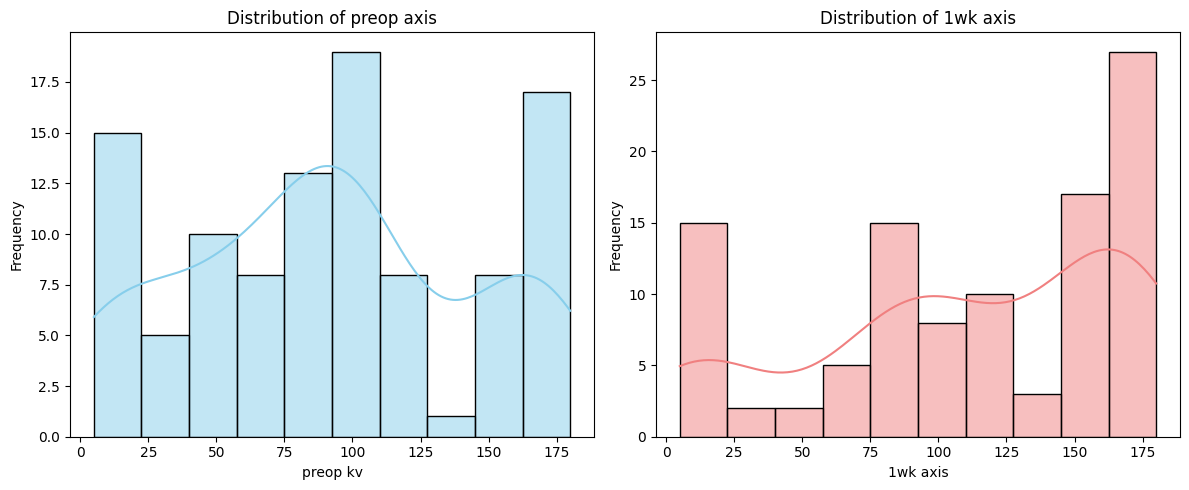

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_filtered, x='preop axis', bins=10, kde=True, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of preop axis')
axes[0].set_xlabel('preop kv')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df_filtered, x='1wk axis', bins=10, kde=True, color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of 1wk axis')
axes[1].set_xlabel('1wk axis')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

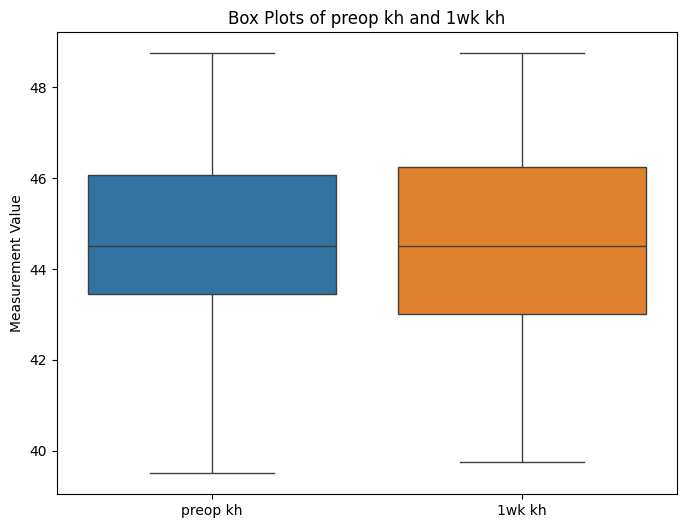

In [112]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_filtered[['preop kh', '1wk kh']])
plt.title('Box Plots of preop kh and 1wk kh')
plt.ylabel('Measurement Value')
plt.show()

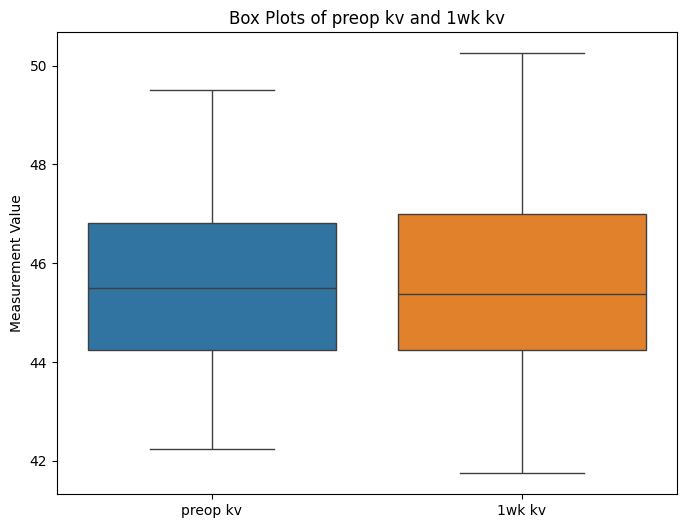

In [113]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_filtered[['preop kv', '1wk kv']])
plt.title('Box Plots of preop kv and 1wk kv')
plt.ylabel('Measurement Value')
plt.show()

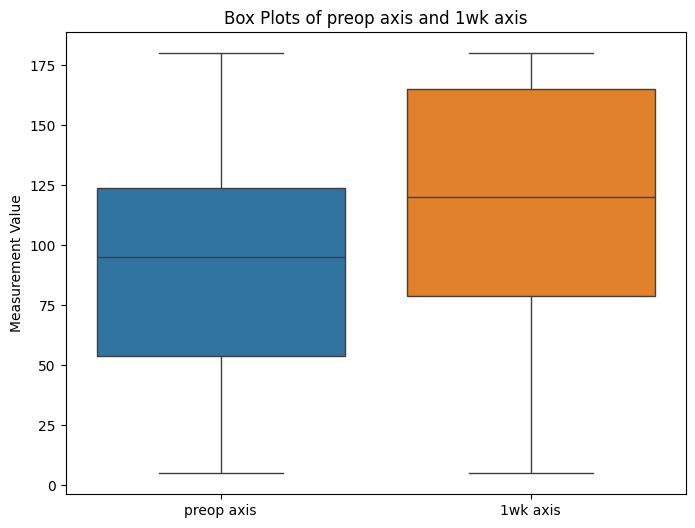

In [114]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_filtered[['preop axis', '1wk axis']])
plt.title('Box Plots of preop axis and 1wk axis')
plt.ylabel('Measurement Value')
plt.show()

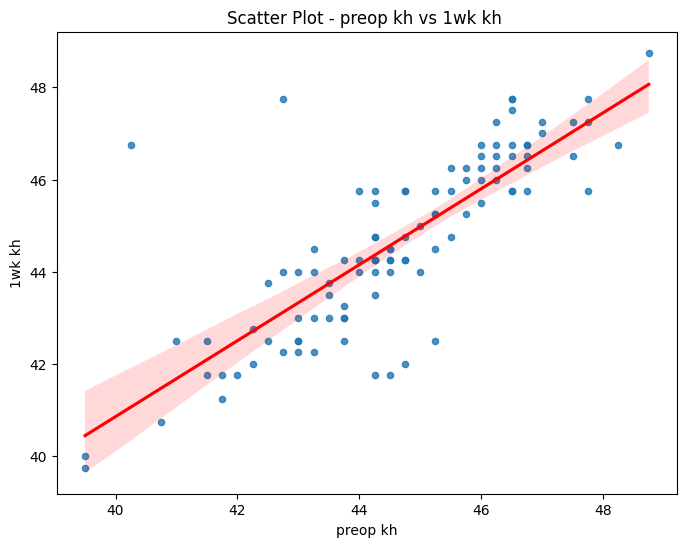

In [115]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_filtered, x='preop kh', y='1wk kh', scatter_kws={'s': 20}, line_kws={'color': 'red'})
plt.title('Scatter Plot - preop kh vs 1wk kh ')
plt.xlabel('preop kh')
plt.ylabel('1wk kh')
plt.show()

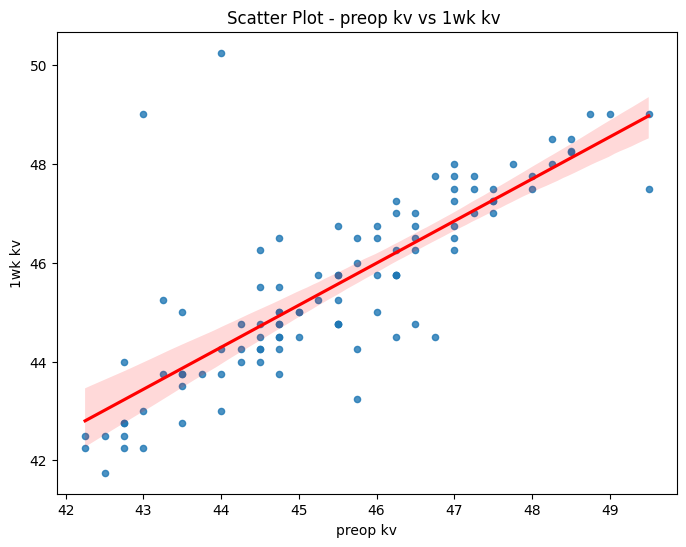

In [116]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_filtered, x='preop kv', y='1wk kv', scatter_kws={'s': 20}, line_kws={'color': 'red'})
plt.title('Scatter Plot - preop kv vs 1wk kv ')
plt.xlabel('preop kv')
plt.ylabel('1wk kv')
plt.show()

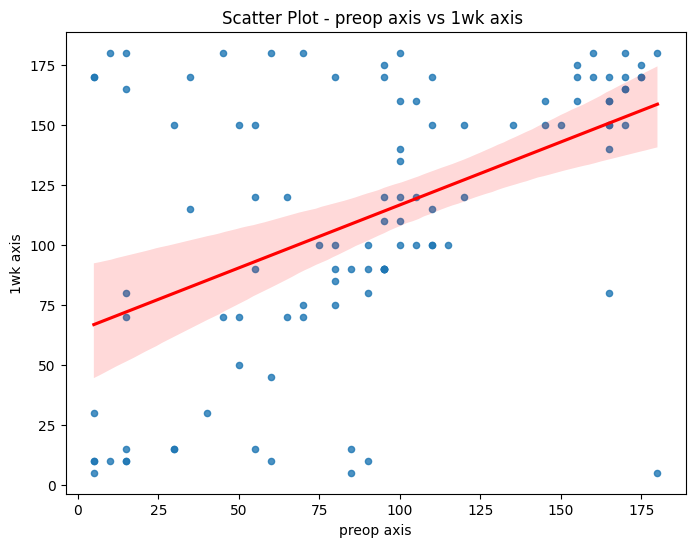

In [117]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_filtered, x='preop axis', y='1wk axis', scatter_kws={'s': 20}, line_kws={'color': 'red'})
plt.title('Scatter Plot - preop axis vs 1wk axis ')
plt.xlabel('preop axis')
plt.ylabel('1wk axis')
plt.show()